# MNIST Recognize

## 1. Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, ConfusionMatrixDisplay

## 2. Load data

In [10]:
train = pd.read_csv('../data/raw/train.csv')
train_y = train['label']
train = train.drop('label', axis = 1)

test = pd.read_csv('../data/raw/test.csv')

## 3. EDA

<Axes: xlabel='label', ylabel='Count'>

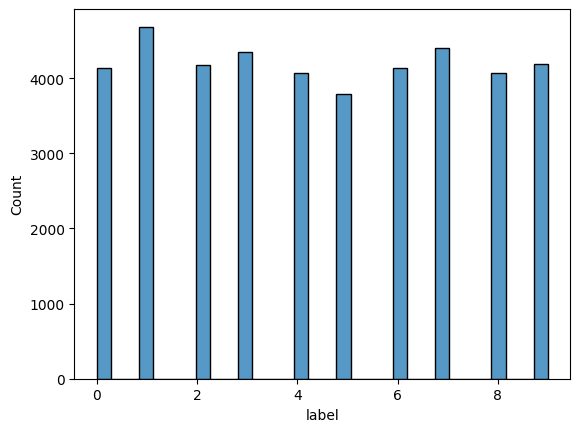

In [18]:
sns.histplot(train_y) # Объектов каждого класса приблизительно равное количество

### Visualizing random digits

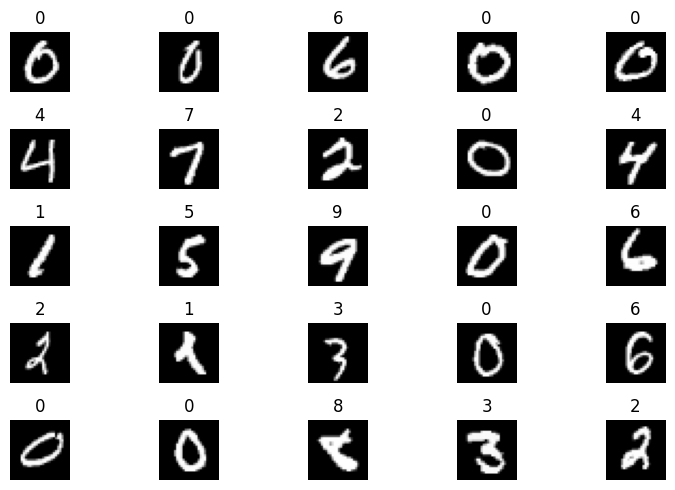

In [ ]:
fig, axes = plt.subplots(5, 5, figsize = (8, 5))
axes = axes.ravel()

с = 8

for i in range(1 * с, 26 * с):
    image = train.iloc[i].values.reshape(28, 28)
    axes[i % 25].imshow(image, cmap = 'grey')
    axes[i % 25].set_title(train_y[i])
    axes[i % 25].axis('off')

Гипотезы на основе анализа n-го количества цифр
1) Большинство нулей смещено относительно центра и имеет толстую обводку своего контура
2) Тройки схожи с пятерками,при этом для 3-ки в центре мы имеем область, в которой одна часть полупетли переходи в другую
3) Единицы представляют из себя обычные "палки", которые при этом почти всегда проходят через центр, и имеют схожие черты с семерками, которые отличаются только дополнительной прямой
4) Пятерки похожи с шестерками, в некоторых случаях отличаются только верхние 'заветушки'
5) Четверки схожи с девятками, и их верхняя часть может 'переходить в друг друга' в разных случаях почерка
6) Многие 8-ки проходят через центр (общая точка двух окружностей)

## Создадим усредненные изображения для цифр
Идея в том, чтобы накладывать изображения друг на друга, усреднять и получить новое изображение, где каждый пиксель будет показывать среднюю 'значимость?' каждого отдельного пикселя

### Mean Image of each class

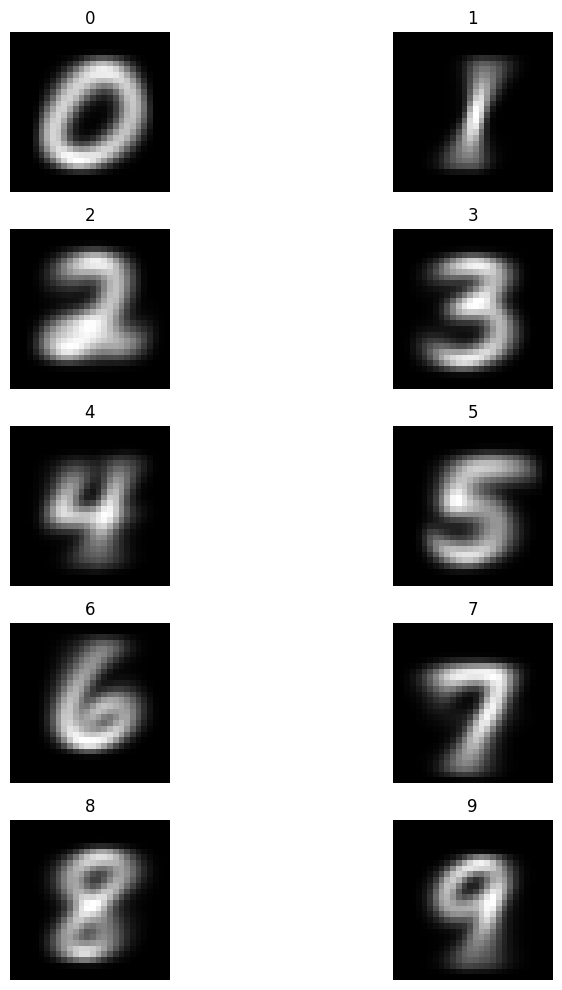

In [ ]:
fig, axes = plt.subplots(5, 2, figsize = (10, 10))
axes = axes.ravel()

# mean_digit = [train[train_y == digit].mean().values.reshape(28, 28) for digit in range(10)]

for digit in range(10):
    mean_digit = train[train_y == digit].mean().values.reshape(28, 28)
    axes[digit].imshow(mean_digit, cmap = 'grey')
    axes[digit].set_title(digit)
    axes[digit].axis('off')

### Variance maps

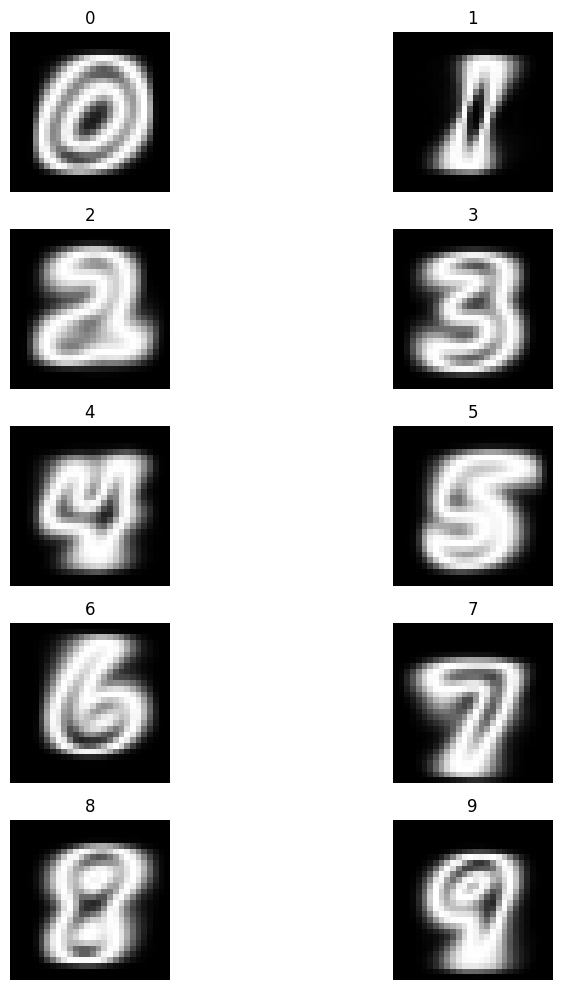

In [ ]:
fig, axes = plt.subplots(5, 2, figsize = (10, 10))
axes = axes.ravel()

#var_digit = [train[train_y == digit].var().values.reshape(28, 28) for digit in range(10)]
binary = (train > 0).astype(int)

for digit in range(10):
    var_digit = binary[train_y == digit].var().values.reshape(28, 28)
    axes[digit].imshow(var_digit, cmap = 'grey')
    axes[digit].set_title(digit)
    axes[digit].axis('off')

## 4. Baseline

In [26]:
X_train, X_valid, y_train, y_valid = train_test_split(train, train_y, train_size = 0.8, random_state = 42)

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lgb.LGBMClassifier(
        objective = 'multiclass',
        num_class = 10,
        metric = 'multi_logloss',
        learning_rate = 0.07,
        subsample = 0.8,
        reg_alpha = 0.1,
        reg_lambda = 0.1
    ))
])

In [83]:
pipeline.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.202685 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 105518
[LightGBM] [Info] Number of data points in the train set: 33600, number of used features: 613
[LightGBM] [Info] Start training from score -2.315767
[LightGBM] [Info] Start training from score -2.186126
[LightGBM] [Info] Start training from score -2.311254
[LightGBM] [Info] Start training from score -2.286641
[LightGBM] [Info] Start training from score -2.341116
[LightGBM] [Info] Start training from score -2.385385
[LightGBM] [Info] Start training from score -2.304969
[LightGBM] [Info] Start training from score -2.259480
[LightGBM] [Info] Start training from score -2.342663
[LightGBM] [Info] Start training from score -2.305566


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LGBMClassifier(learning_rate=0.07, metric='multi_logloss',
                                num_class=10, objective='multiclass',
                                reg_alpha=0.1, reg_lambda=0.1,
                                subsample=0.8))])

In [84]:
pred = pipeline.predict(X_valid)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [85]:
accuracy_score(y_valid, pred)

0.9710714285714286

### Error Analysis for Logistic Regression

In [28]:
X_train = X_train / 255
X_valid = X_valid / 255

In [29]:
model = LogisticRegression(max_iter = 1000, random_state = 42)

In [30]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [31]:
pred = model.predict(X_valid)

In [32]:
accuracy_score(y_valid, pred)

0.919404761904762

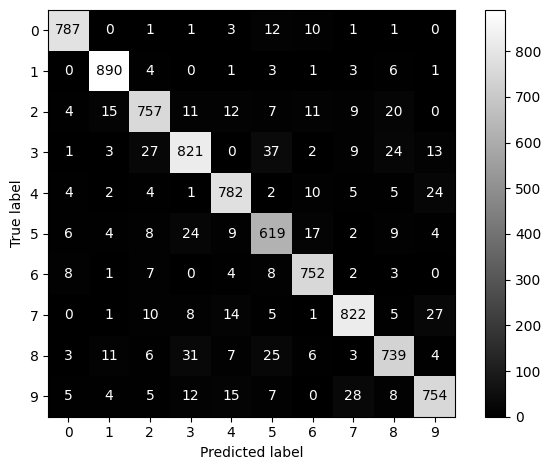

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    pred,
    cmap = 'grey'
)

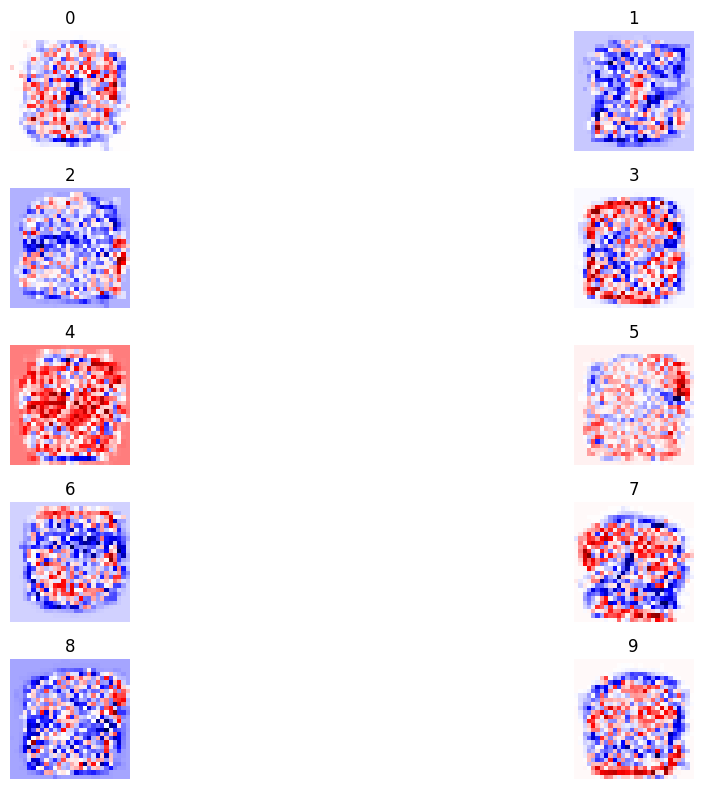

In [ ]:
fig, axes = plt.subplots(5, 2, figsize = (16, 8))
axes = axes.ravel()

for i in range(10):
    pict = np.reshape(model.coef_[i], (28, 28))
    axes[i].imshow(pict, cmap = 'seismic')
    axes[i].set_title(i)
    axes[i].axis('off')

In [23]:
mask = (pred == 3) & (y_valid == 5)

In [24]:
X_errors = X_valid[mask]
y_errors = y_valid[mask]

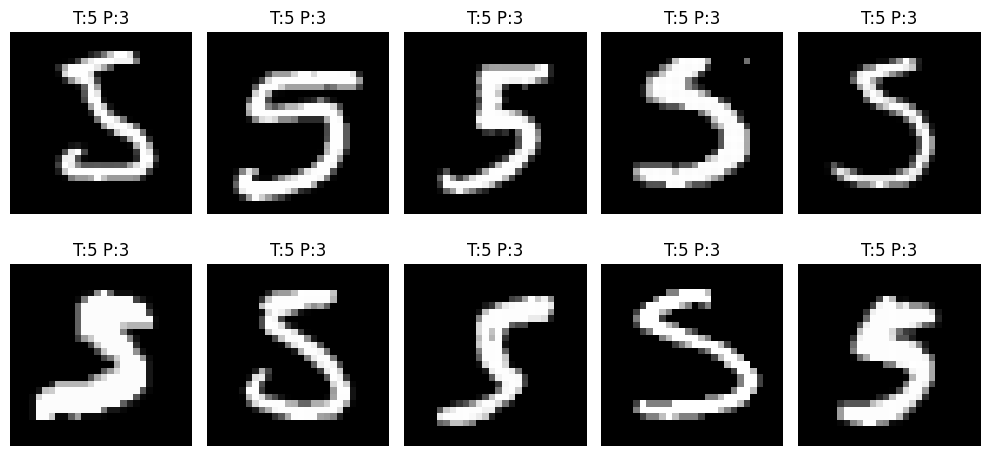

In [25]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i, ax in enumerate(axes):
    image = X_errors.iloc[i].values.reshape(28, 28)

    ax.imshow(image, cmap='gray')
    ax.set_title(f"T:{y_errors.iloc[i]} P:3")
    ax.axis("off")

plt.tight_layout()

## 5. Final

In [86]:
submission = pd.read_csv('/kaggle/input/competitions/digit-recognizer/sample_submission.csv')

In [87]:
prediction = pipeline.predict(test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [88]:
submission['Label'] = prediction

In [89]:
submission.to_csv(
    "submission.csv",
    index=False
)